# 5. Marketing says the flat count hides customers lost and replaced: were any lost, who slowed instead, and which segment fell most?

**Week 1, Tuesday. Chapter 5 of 6.** Chapter 4 found the rise in revenue per order about 69 percent mix, Rs 22,902 of Rs 33,231: 25
small orders from Retail-Plus, Kalpa's paid membership tier, disappeared, and no consumer segment
paid meaningfully more. Chapter 2 had counted 69 customers in each quarter, a flat count. Marketing
now attacks the findings on three fronts. This chapter adds two tools: a set of customer ids per
quarter, which answers the churn claim, and a small helper that turns two numbers into a percentage
change, which has to be checked before anyone trusts its summary.

> **Marketing pushes back.** "A flat count can hide churn replaced by new customers, which is why we
> need acquisition. And Retail-Plus is Rs 65,250 out of a Rs 23 lakh fall; it does not matter. Last
> quarter's summary script says Business fell most."
>
> The marketing lead, Kalpa Retail

**Who needs the answer.** Meera Raghavan, the CEO, decides whether to release the Rs 12 crore acquisition budget, and Marketing
now rests it on churn, customers lost and replaced by new ones, hiding inside a flat count. A wrong
answer spends crores replacing customers who never left, while the ones who slowed keep slowing.

**The questions on the way.**

1. Which of four tests can see customers lost and customers new?
2. How many of Q1's 69 customers are missing from Q2?
3. Who placed fewer orders in Q2?
4. Which segment's orders per customer fell most?
5. Is Retail-Plus too small to matter at Rs 65,250?
6. Do each customer's first and last order dates find anyone lost or new?

**The need.** Marketing's Rs 12 crore rests on one claim: Kalpa is losing customers, which is churn,
and must replace them. The metric at stake is retention, the customers of Q1 who bought again in Q2,
and its mirror, the new customers of Q2. The decision riding on it is the acquisition budget itself,
and a wrong answer can also leave a retention problem to run while the money goes elsewhere.

**Who else faces this.** Membership businesses weigh the same two arguments, winning new
customers against keeping the ones they have buying. Harvard Business Review summarised the studies
behind the second: depending on the study and the industry, acquiring a new customer costs 5 to 25
times more than retaining an existing one,
and Bain's Frederick Reichheld found that a 5 percent rise in retention lifts profits by 25 to 95
percent (Amy Gallo, HBR, 29 October 2014, checked 30 Sep 2026). Those are estimates across
industries and say nothing about Kalpa's own costs, so the reply asks Finance for Kalpa's acquisition
cost. Swiggy shows why the two branches are reported apart: in the quarter to September 2025 its monthly
transacting users, the people who ordered at least once in a month, rose 34.0 percent in a year to
22.9 million while orders per user a month fell from 4.53 to 4.10 (Swiggy, Q2 FY2026 shareholder
letter, checked 30 Sep 2026). A count and a frequency can move apart, so each is reported on its own:
Swiggy's count rose while its frequency fell, and Kalpa's count held while its frequency fell.

Kavya Nair, the team's senior analyst, reviews every number before it leaves.

> **Kavya's review of chapter 4.** "You told Marketing the consumer segments did not pay more.
> Expect them to come back with a better argument, and answer it with a check they can run
> themselves."

**Setup.** The first lines import the helper as `kit`, load the export, group it as chapter 3 did,
carry `tree_for` and `describe`, and run `tree_for` on every segment in both quarters, into `q1` and
`q2`.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
ORDERS = kit.load_records("C2_W01_D02_orders_STUDENT.py")
SEGMENTS = ["Retail-Core", "Retail-Plus", "Business", "Student"]
groups = {"Q1": {}, "Q2": {}}       # quarter -> segment -> list of orders
by_quarter = {"Q1": [], "Q2": []}
for order in ORDERS:
    q, seg = order["quarter"], order["segment"]
    groups[q].setdefault(seg, []).append(order)
    by_quarter[q].append(order)


def tree_for(rows):
    """The revenue tree's leaves for any list of orders, returned as a dictionary (chapter 3)."""
    revenue = 0
    seen = {}
    for order in rows:
        revenue += order["amount"]
        seen[order["customer_id"]] = True
    orders = len(rows)
    customers = len(seen)
    return {"revenue": revenue, "orders": orders, "customers": customers,
            "orders_per_customer": orders / customers,
            "revenue_per_order": revenue / orders}


def describe(amounts):
    """A group's typical value and spread: median, min, max and range (chapter 3)."""
    ordered = sorted(amounts)
    n = len(ordered)
    if n % 2 == 1:
        median = ordered[n // 2]
    else:
        median = (ordered[n // 2 - 1] + ordered[n // 2]) / 2
    return {"median": median, "min": ordered[0], "max": ordered[-1], "range": ordered[-1] - ordered[0]}

q1 = {seg: tree_for(groups["Q1"][seg]) for seg in SEGMENTS}
q2 = {seg: tree_for(groups["Q2"][seg]) for seg in SEGMENTS}
print("segments carried from chapter 3:", ", ".join(SEGMENTS))

segments carried from chapter 3: Retail-Core, Retail-Plus, Business, Student


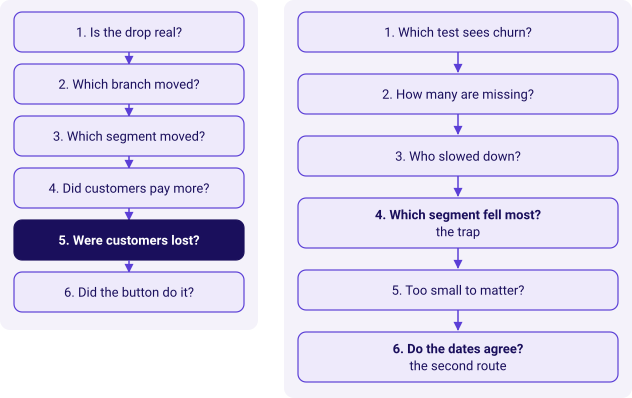

In [2]:
kit.side_by_side(
    kit.ladder(['Is the drop real?', 'Which branch moved?', 'Which segment moved?', 'Did customers pay more?', 'Were customers lost?', 'Did the button do it?'], lit=4, show=False),
    kit.vflow(['1. Which test sees churn?', '2. How many are missing?', '3. Who slowed down?', '4. Which segment fell most?\nthe trap', '5. Too small to matter?', '6. Do the dates agree?\nthe second route'], show=False),
)

## 1. Which of four tests can see customers lost and customers new?

A team could test "a flat count hides churn replaced by new customers" in four ways.

| Option | How | Can it see churn? |
|---|---|---|
| A. Compare the counts | 69 in Q1 against 69 in Q2 | No: a count is net, so 20 lost and 20 new also give 69 and 69 |
| B. The id overlap | A set of ids per quarter; in both, only in Q1, only in Q2 | Yes, lost and new named separately |
| C. Customer by customer | Each id's Q1 and Q2 orders side by side | Yes, and who slowed down as well |
| D. Ask Marketing's CRM | New sign-ups by month from the campaign system | Only new customers, from a second system to reconcile |

On this file each test is sized by what it gives Meera to read, whether it sees lost and new
customers, and what it assumes.

Option,Output to read,Sees lost and new?,What it assumes
A. counts,2 numbers,no,nothing: a count is net
B. id overlap,3 numbers,yes,one id per person
C. customer by customer,69 rows,"yes, and who slowed",one id per person
D. Marketing's CRM,sign-ups by month,new only,the CRM and the export share their ids


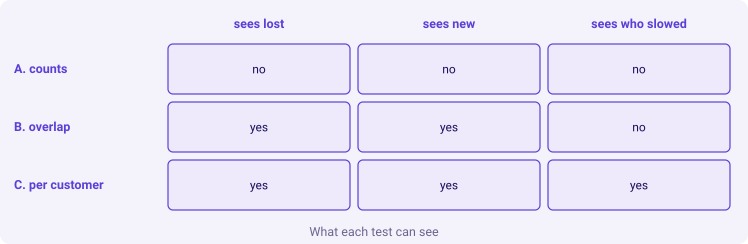

In [3]:
ids = {"Q1": set(), "Q2": set()}
per_customer = {"Q1": {}, "Q2": {}}
for order in ORDERS:
    q, cid = order["quarter"], order["customer_id"]
    ids[q].add(cid)
    per_customer[q][cid] = per_customer[q].get(cid, 0) + 1
kit.table(["Option", "Output to read", "Sees lost and new?", "What it assumes"],
          [("A. counts", "2 numbers", "no", "nothing: a count is net"),
           ("B. id overlap", "3 numbers", "yes", "one id per person"),
           ("C. customer by customer", f"{len(ids['Q1'] | ids['Q2'])} rows", "yes, and who slowed", "one id per person"),
           ("D. Marketing's CRM", "sign-ups by month", "new only", "the CRM and the export share their ids")],
          caption="Sizing four tests of the churn claim")
kit.matrix(["A. counts", "B. overlap", "C. per customer"], ["sees lost", "sees new", "sees who slowed"],
           [["no", "no", "no"], ["yes", "yes", "no"], ["yes", "yes", "yes"]],
           title="What each test can see")
kit.check("the two quarters hold 69 distinct customer ids between them", len(ids["Q1"] | ids["Q2"]) == 69)

**The best-fit call.** Option B, the id overlap, because it answers Marketing's claim exactly, lost
and new, in three numbers anyone can rerun; option C follows it because the next question is who
slowed. **The fact that would change the call:** if the ids were not stable, for example if the
store and the app gave the same person two ids, the overlap would invent churn, and the CRM, option
D, would be needed to join them first.

## 2. How many of Q1's 69 customers are missing from Q2?

**Predict before you run.** How many of Q1's 69 customers are missing from Q2? a) about 20, replaced
by 20 new ones; b) about 5; c) none; d) it cannot be told from one export.

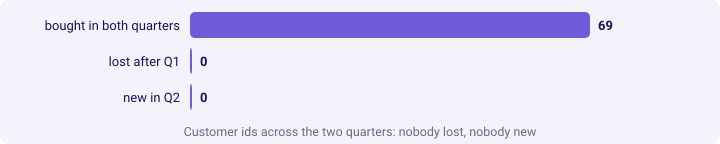

In [4]:
both = ids["Q1"] & ids["Q2"]
lost = ids["Q1"] - ids["Q2"]
new = ids["Q2"] - ids["Q1"]
kit.bars([("bought in both quarters", len(both)), ("lost after Q1", len(lost)), ("new in Q2", len(new))],
         title="Customer ids across the two quarters: nobody lost, nobody new")
kit.check("all 69 customers bought in both quarters", len(both) == 69, f"{len(both)}")
kit.check("no customer was lost and none was new", len(lost) == 0 and len(new) == 0, f"{len(lost)} lost, {len(new)} new")

**What happened.** The answer is c. Every one of the 69 Q2 customers bought in Q1: none lost, none
new. The flat count hides no churn, and acquisition has nothing to replace on this file.

## 3. Who placed fewer orders in Q2?

This is option C: each customer's orders in Q2 minus their orders in Q1.

**Predict before you run.** Of the customers who placed fewer orders in Q2, how many are Retail-Plus
members? a) about a quarter; b) about half; c) most of them; d) none.

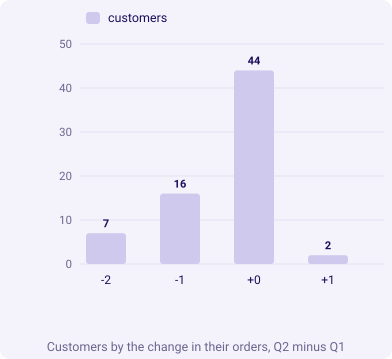

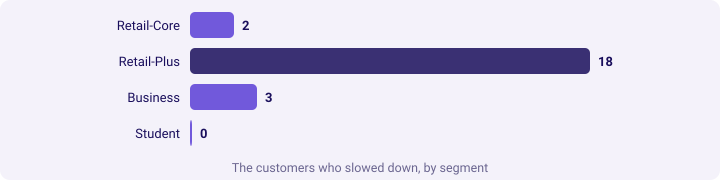

In [5]:
segment_of = {o["customer_id"]: o["segment"] for o in ORDERS}
change_count = {}
slowed_by_segment = {}
for cid in ids["Q1"]:
    d = per_customer["Q2"].get(cid, 0) - per_customer["Q1"][cid]
    change_count[d] = change_count.get(d, 0) + 1
    if d < 0:
        slowed_by_segment[segment_of[cid]] = slowed_by_segment.get(segment_of[cid], 0) + 1
kit.columns([f"{d:+d}" for d in sorted(change_count)], [("customers", [change_count[d] for d in sorted(change_count)])],
            title="Customers by the change in their orders, Q2 minus Q1")
kit.bars([(seg, slowed_by_segment.get(seg, 0)) for seg in SEGMENTS], lit=[1],
         title="The customers who slowed down, by segment")
kit.check("23 customers placed fewer orders in Q2", sum(slowed_by_segment.values()) == 23)
kit.check("18 of the 23 are Retail-Plus members", slowed_by_segment.get("Retail-Plus", 0) == 18)

**What happened.** The answer is c. Twenty-three customers placed fewer orders, and eighteen of them
are Retail-Plus members; 44 customers ordered exactly as often as before. The fall is people Kalpa
already has, buying less often, and most of them pay for membership.

## 4. Which segment's orders per customer fell most?

Marketing's third point comes from a colleague's script, left over from last quarter's report. Run it
exactly as it is, then read what the summary says.

**Predict before you run.** The script summarises the fall in orders per customer by segment. Which
segment will it say fell most? a) Retail-Plus; b) Business; c) Retail-Core; d) Student.

**The plausible wrong answer.** The script runs, prints a tidy summary, and nobody counts what came
back.

In [6]:
def pct_change(before, after):
    change = 100 * (after - before) / before
    if abs(change) > 30:
        print(f"  check by hand: {change:+.1f}%")
    else:
        return round(change, 1)

changes = {}
for seg in SEGMENTS:
    changes[seg] = pct_change(q1[seg]["orders_per_customer"], q2[seg]["orders_per_customer"])
falls = {}
for seg, ch in changes.items():
    if ch and ch < 0:
        falls[seg] = ch
print("summary:", falls)
print("orders per customer fell in every segment, most in Business,", min(falls.values()), "percent")
kit.check("the summary names Business as the largest fall", min(falls, key=falls.get) == "Business")

  check by hand: -49.0%
  check by hand: +40.0%
summary: {'Retail-Core': -5.3, 'Business': -15.0}
orders per customer fell in every segment, most in Business, -15.0 percent


**Why it is wrong.** The answer to the prediction is b, and it is the wrong answer. `pct_change`
prints its warning for any change larger than 30 percent and returns nothing, so Python hands back
`None`. The filter `if ch and ch < 0` then drops every `None` without a word. Retail-Plus, whose
orders per member halved, is exactly the kind of large change the script was written to flag, and it
fell out of the summary. The decision it misleads: Meera opens Business accounts first, and the head
of Retail-Plus is told his tier is not in the table.

**The check.** Count the groups in and the groups out: four segments went in.

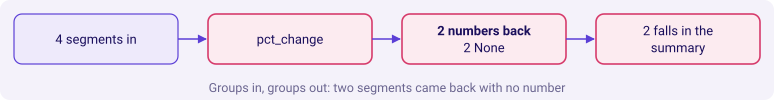

In [7]:
none_back = [seg for seg, ch in changes.items() if ch is None]
kit.flow(["4 segments in", "pct_change", f"{len(SEGMENTS) - len(none_back)} numbers back\n{len(none_back)} None",
          f"{len(falls)} falls in the summary"], kinds=["plain", "bad", "bad", "bad"],
         title="Groups in, groups out: two segments came back with no number")
kit.check("two of the four segments came back as None", len(none_back) == 2, ", ".join(none_back))

**The fix.** Return the change every time, in the same type, and put the "check by hand" flag in a
column of its own, so a large move stays in the summary with its flag beside it.

Segment,Q1,Q2,Change,Flag
Retail-Core,1.12,1.06,-5.3%,
Retail-Plus,2.32,1.18,-49.0%,check by hand
Business,1.82,1.55,-15.0%,
Student,2.50,3.50,+40.0%,check by hand


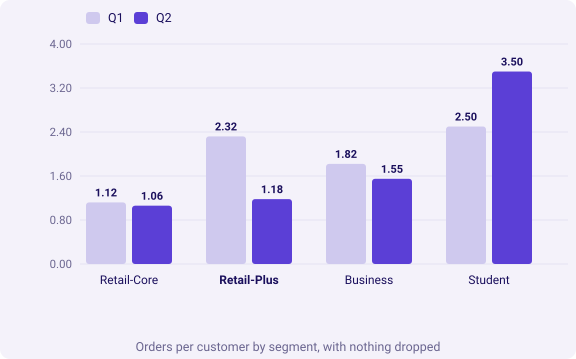

In [8]:
def pct_change_fixed(before, after):
    return round(100 * (after - before) / before, 1)

fixed = {seg: pct_change_fixed(q1[seg]["orders_per_customer"], q2[seg]["orders_per_customer"]) for seg in SEGMENTS}
kit.table(["Segment", "Q1", "Q2", "Change", "Flag"],
          [(seg, f'{q1[seg]["orders_per_customer"]:.2f}', f'{q2[seg]["orders_per_customer"]:.2f}', f"{fixed[seg]:+.1f}%",
            "check by hand" if abs(fixed[seg]) > 30 else "") for seg in SEGMENTS],
          caption="Orders per customer: every segment, every change")
kit.columns(SEGMENTS, [("Q1", [round(q1[s]["orders_per_customer"], 2) for s in SEGMENTS]),
                       ("Q2", [round(q2[s]["orders_per_customer"], 2) for s in SEGMENTS])],
            fmt=lambda v: f"{v:.2f}", lit=[1], title="Orders per customer by segment, with nothing dropped")
kit.check("the fixed summary has a number for every segment", None not in fixed.values() and len(fixed) == 4)
kit.check("Retail-Plus fell 49.0 percent and Student rose 40.0", (fixed["Retail-Plus"], fixed["Student"]) == (-49.0, 40.0))

**What changed.** "Business fell most, 15.0 percent" became "Retail-Plus fell 49.0 percent, 2.32 to
1.18 orders per member, and Business 15.0 percent on three orders". Student, which rose, also came
back as `None` from the broken script, and the filter would have dropped it anyway because it rose.

## 5. Is Retail-Plus too small to matter at Rs 65,250?

Marketing's rupee point is correct arithmetic and the wrong comparison. Business orders run to lakhs
and consumer orders to a few thousand rupees, so a consumer segment is judged against the consumer
business, the three segments other than Business.

**Predict before you run.** What share of the consumer business's fall is Retail-Plus? a) about 3
percent; b) about a third; c) about 93 percent; d) all of it.

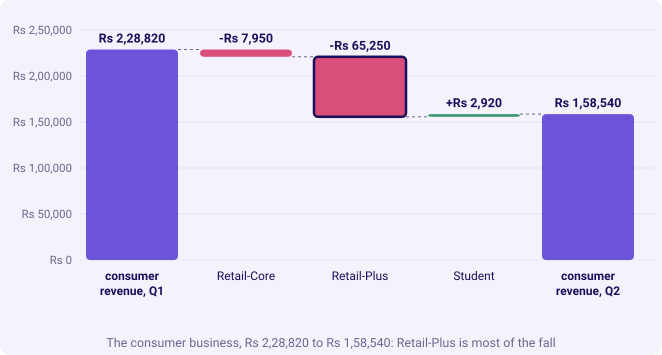

In [9]:
CONSUMER = ["Retail-Core", "Retail-Plus", "Student"]
consumer_q1 = sum(q1[s]["revenue"] for s in CONSUMER)
consumer_q2 = sum(q2[s]["revenue"] for s in CONSUMER)
consumer_fall = consumer_q1 - consumer_q2
plus_fall = q1["Retail-Plus"]["revenue"] - q2["Retail-Plus"]["revenue"]
kit.bridge(("consumer revenue, Q1", consumer_q1), [(s, q2[s]["revenue"] - q1[s]["revenue"]) for s in CONSUMER],
           end_label="consumer revenue, Q2", lit=[1],
           title="The consumer business, Rs 2,28,820 to Rs 1,58,540: Retail-Plus is most of the fall")
kit.check("the consumer business fell Rs 70,280", consumer_fall == 70280, kit.rupees(consumer_fall))
kit.check("Retail-Plus is 93 percent of the consumer fall", round(plus_fall / consumer_fall * 100) == 93,
          f"{plus_fall / consumer_fall * 100:.1f}")

**What happened.** The answer is c. Retail-Plus is Rs 65,250 of the Rs 70,280 consumer fall, 93
percent, and 25 of the 28 lost orders. The rupee fall in Business is three orders out of twenty,
each worth lakhs, so one account ordering early or late moves it by lakhs. The two
findings go to Meera side by side: the rupees in Business, with their caveat, and the behaviour in
Retail-Plus, with its count.

## 6. Do each customer's first and last order dates find anyone lost or new?

The overlap in question 2 trusted the `quarter` field and set arithmetic. A second route uses only the
dates: each customer's first and last order in the export. A customer whose first order falls in Q2
is new, and one whose last order falls in Q1 was lost. If the quarter field were wrong, or the sets
had been built on the wrong field, the two routes would disagree.

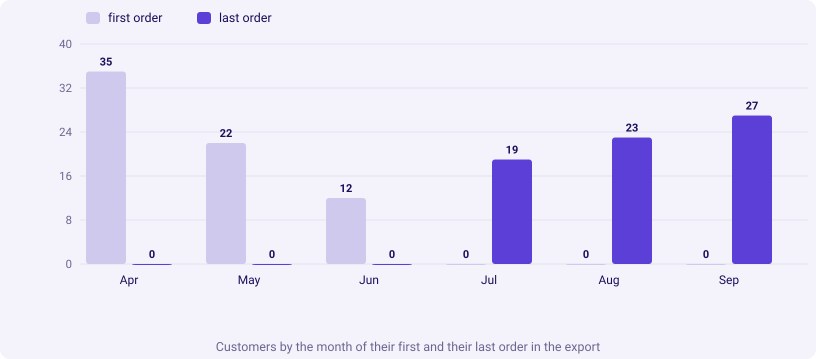

Route,New in Q2,Lost after Q1
"the id overlap, question 2",0,0
first and last dates,0,0


In [10]:
first, last = {}, {}
for order in ORDERS:
    cid, d = order["customer_id"], order["order_date"]
    first[cid] = min(first.get(cid, d), d)
    last[cid] = max(last.get(cid, d), d)
new_by_date = [cid for cid in first if first[cid] >= "2026-07-01"]
lost_by_date = [cid for cid in last if last[cid] <= "2026-06-30"]
MONTHS = ["2026-04", "2026-05", "2026-06", "2026-07", "2026-08", "2026-09"]
firsts = [sum(1 for d in first.values() if d[:7] == m) for m in MONTHS]
lasts = [sum(1 for d in last.values() if d[:7] == m) for m in MONTHS]
kit.columns(["Apr", "May", "Jun", "Jul", "Aug", "Sep"], [("first order", firsts), ("last order", lasts)],
            title="Customers by the month of their first and their last order in the export")
kit.table(["Route", "New in Q2", "Lost after Q1"],
          [("the id overlap, question 2", len(new), len(lost)), ("first and last dates", len(new_by_date), len(lost_by_date))],
          caption="Lost and new, counted two ways")
kit.check("the dates find the same lost and new counts as the overlap", (len(new_by_date), len(lost_by_date)) == (len(new), len(lost)))

The dates agree with the overlap and find no one lost and no one new: every customer's first order
falls in Q1 and every last order in Q2.

**When to switch.** Show Marketing the overlap, since it names lost and new in three numbers. The
dates add a warning the overlap cannot: a first order in this export is only the first since
1 April, so on a longer question "new" needs each customer's whole history, which the CRM holds.

> **Kavya's review.** "Marketing made three attacks and you answered each with a check anyone can
> rerun: the overlap for churn, groups in and out for the script, and the consumer business for
> size. And you nearly shipped a summary that lost the one segment that matters. Count what comes
> back from every helper you did not write."

### In the interview: how do you answer Marketing's churn claim, and why does a helper that prints and returns nothing break a pipeline?

The tags mark how often a question comes up: [S] a staple asked everywhere, [F] frequent in GCC and product screens, [SV] a service-major screen opener, [D] a differentiator.

**[D] Marketing insists the answer is acquisition and your data says frequency; how do you make the
case in the room?** "I take their claim seriously and test it in its own terms, with a check they can
repeat. Acquisition predicts more customers, or churn replaced by new ones, so I show the count, 69
and 69, and the overlap: every Q2 customer bought in Q1, none lost, none new. Then I show where the
fall is, orders per customer from 1.65 to 1.25, and in the consumer business Retail-Plus is 93
percent of the fall. I end on what would change my mind, which keeps it a question of evidence."
The interviewer is listening for the test that would falsify Marketing's claim, and a calm tone.

**[F] Why does a function that prints its answer and returns nothing break a pipeline?** "Printing
sends the answer to the screen and returns `None` to the caller. The next step receives `None` and either
crashes or, worse, carries on: here a filter dropped every `None` and two of four segments vanished
from the summary, including the one that fell 49 percent. A function returns its answer every time,
in the same type, and a flag goes in its own column." The interviewer is listening for `None`, the
silent case, and computing kept apart from showing.

**[SV] The customer count is flat quarter on quarter; does that prove no customers were lost?** "No,
because a count is net. The test is the overlap of ids: in both periods, only in the first, only in the
second. Here it came out 69, 0 and 0." The interviewer is listening for overlap, lost and new.

**The design question. How would you test "a flat count hides churn", and what would make you
distrust your own test?** "The id overlap, because it names lost and new separately in three numbers.
I would distrust it if one person can hold two ids, say one from the store and one from the app,
since then the overlap invents churn; I would join the ids through the CRM first." The interviewer
is listening for the assumption under the test.

### Depth: what does the overlap report when one person holds two ids?

The overlap counts ids, so it is right only while each person holds one id. Try it: invent five
orders where one customer shops in the store as `C-9001` and in the app as `C-9002`, and show that
the overlap reports one lost and one new customer who is the same person.

References for the chapter:

- Amy Gallo, "The Value of Keeping the Right Customers", Harvard Business Review, 29 October 2014: https://hbr.org/2014/10/the-value-of-keeping-the-right-customers (verified 30 Sep 2026)
- Python docs, sets: https://docs.python.org/3/tutorial/datastructures.html#sets (verified 30 Sep 2026)

## So, were customers lost?

1. Of the four tests, the id overlap sees lost and new customers in three numbers anyone can rerun, and looking customer by customer then shows who slowed.
2. None of Q1's 69 customers is missing from Q2: 69 bought in both quarters, 0 only in Q1 and 0 only in Q2.
3. Twenty-three customers placed fewer orders in Q2, 18 of them Retail-Plus members, and 44 ordered as often as before.
4. Retail-Plus fell most, 2.32 to 1.18 orders per member, minus 49.0 percent; last quarter's summary script said Business, 15.0 percent, because its helper printed a warning and returned nothing for any change above 30 percent, so Retail-Plus and Student came back as None and the filter dropped them.
5. Retail-Plus is not too small to matter: its Rs 65,250 is 93 percent of the Rs 70,280 consumer fall and 25 of the 28 lost orders, while the Business rupees are three lakh-sized orders that one account's timing moves.
6. Each customer's first and last order dates find no one lost or new: every first order falls in Q1 and every last order in Q2.

No customer was lost and none is new. Twenty-three existing customers bought less often, 18 of them
members, and Retail-Plus fell 49.0 percent per member while the broken script said Business.

In [11]:
kit.check_summary()
print("Next, chapter 6. How much of the Retail-Plus fall can the broken reorder button explain, and "
      "what evidence goes in Meera's memo?")

Next, chapter 6. How much of the Retail-Plus fall can the broken reorder button explain, and what evidence goes in Meera's memo?
